<a href="https://colab.research.google.com/github/MexicoHamburger/AIP-2/blob/main/CarrerPrediction_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TabTransformer Multi‑Task Workflow
엔드‑투‑엔드 예시 노트북 (10 % 샘플·train/val/test 분할 포함)

> Stack Overflow Dev Survey 2024 전처리 결과 CSV를 업로드한 뒤, **`DATA_CSV` 변수 경로만 수정**하고 셀을 순서대로 실행하세요.

In [2]:
!pip install pandas scikit-learn torch tabtransformer-pytorch matplotlib --quiet

ERROR: Could not find a version that satisfies the requirement tabtransformer-pytorch (from versions: none)
ERROR: No matching distribution found for tabtransformer-pytorch


## 1. 데이터 로드 & 10 % 샘플링

In [1]:
import pandas as pd, numpy as np, os, random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from google.colab import files
import io

# --- 파일 업로드 ---
uploaded = files.upload()
filename = next(iter(uploaded))
DATA_CSV = filename

# --- 다중-라벨 컬럼 정의 ---
multi_cols = [
    "LanguageHaveWorkedWith", "LanguageWantToWorkWith",
    "DatabaseHaveWorkedWith", "DatabaseWantToWorkWith",
    "PlatformHaveWorkedWith", "PlatformWantToWorkWith",
    "WebframeHaveWorkedWith", "WebframeWantToWorkWith",
    "EmbeddedHaveWorkedWith", "EmbeddedWantToWorkWith",
    "MiscTechHaveWorkedWith", "MiscTechWantToWorkWith",
    "ToolsTechHaveWorkedWith", "ToolsTechWantToWorkWith",
    "ProfessionalTech",
]

def split_pipe(x):
    return [] if pd.isna(x) else [i.strip() for i in x.split(";")]

# --- 파일 읽기 ---
raw = pd.read_csv(io.BytesIO(uploaded[DATA_CSV]))

# 문자열 → 리스트 변환
for c in multi_cols:
    if c in raw.columns:
        raw[c] = raw[c].apply(split_pipe)

# 핵심 숫자 결측 제거
raw = raw.dropna(subset=["CompTotal", "JobSat"])
print("샘플 수:", len(raw))
raw.head(3)


Saving SODC_2024.csv to SODC_2024.csv
샘플 수: 12275


,DevType,CompTotal,LanguageHaveWorkedWith,LanguageWantToWorkWith,DatabaseHaveWorkedWith,DatabaseWantToWorkWith,PlatformHaveWorkedWith,PlatformWantToWorkWith,WebframeHaveWorkedWith,WebframeWantToWorkWith,EmbeddedHaveWorkedWith,EmbeddedWantToWorkWith,MiscTechHaveWorkedWith,MiscTechWantToWorkWith,ToolsTechHaveWorkedWith,ToolsTechWantToWorkWith,ProfessionalTech,ProfessionalQuestion,Industry,JobSat
1,Data scientist or machine learning specialist,127500000.0,"[JavaScript, Python, SQL, TypeScript]","[Go, JavaScript, Python, Rust, SQL, TypeScript]","[PostgreSQL, SQLite]","[PostgreSQL, SQLite]","[Amazon Web Services (AWS), Cloudflare, Digita...","[Amazon Web Services (AWS), Cloudflare, Google...","[Next.js, React, Vue.js]","[Svelte, Vue.js]",[],[],"[NumPy, Pandas, Scikit-Learn, Torch/PyTorch]","[NumPy, Pandas, Scikit-Learn, Torch/PyTorch]","[Ansible, Make, Vite]",[Vite],[Developer portal or other central places to f...,AI-powered search (paid),Computer Systems Design and Services,10.0
2,Engineering manager,214914000.0,"[C#, HTML/CSS, Java, JavaScript, Python, TypeS...","[HTML/CSS, JavaScript, Python, TypeScript]","[Oracle, PostgreSQL]","[PostgreSQL, Redis]",[Amazon Web Services (AWS)],[Amazon Web Services (AWS)],[React],[React],[],[],[],[],"[Gradle, Maven (build tool)]","[Gradle, Maven (build tool)]",[],Traditional public search engine,Retail and Consumer Services,7.0
3,"Developer, full-stack",267150000.0,"[Bash/Shell (all shells), C#, HTML/CSS, JavaSc...","[C#, HTML/CSS, JavaScript, SQL, TypeScript]","[Microsoft SQL Server, PostgreSQL]","[Microsoft SQL Server, MongoDB, PostgreSQL]",[Microsoft Azure],"[Amazon Web Services (AWS), Google Cloud, Micr...","[Angular, ASP.NET CORE, React]","[Angular, ASP.NET CORE, Htmx, jQuery, React]",[],[],"[.NET (5+), RabbitMQ, React Native]","[.NET (5+), Flutter, RabbitMQ, React Native]","[Chocolatey, Docker, Visual Studio Solution, Y...","[Docker, Visual Studio Solution]","[DevOps function, Automated testing, Observabi...",Traditional public search engine,Healthcare,5.0


## 2. Multi‑Label Binarizer → 입·출력 행렬

In [3]:
# --- 입력 X ---
mlb = {c: MultiLabelBinarizer().fit(raw[c]) for c in multi_cols}
X_parts = [mlb[c].transform(raw[c]) for c in multi_cols]
X = np.hstack(X_parts).astype("float32")

# --- 다중-라벨 타깃 ---
y_role = raw["DevType"].str.get_dummies(";").astype("float32").values
y_ind  = raw["Industry"].str.get_dummies(";").astype("float32").values
n_role = y_role.shape[1]

# --- 연봉 전처리 ---
comp = raw["CompTotal"].values.astype("float64")
q99 = np.nanpercentile(comp, 99)
valid_mask = (comp < q99) & (~np.isnan(comp))
scaler = StandardScaler()
scaled_valid = scaler.fit_transform(comp[valid_mask].reshape(-1, 1)).flatten()
y_sal_scalar = np.full_like(comp, np.nan, dtype="float32")
y_sal_scalar[valid_mask] = scaled_valid.astype("float32")
y_sal_mat = np.tile(y_sal_scalar[:, None], (1, n_role))
y_sal_role = np.where(y_role == 1, y_sal_mat, np.nan).astype("float32")

# --- 만족도 전처리 ---
y_sat_scalar = raw["JobSat"].astype("float32").values
y_sat_mat = np.tile(y_sat_scalar[:, None], (1, n_role))
y_sat_role = np.where(y_role == 1, y_sat_mat, np.nan).astype("float32")


In [6]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

# 1) 실제 존재하는 컬럼만 사용
skill_cols = [col for col in multi_cols if col in raw.columns]
skill_space = sorted({s for col in skill_cols for row in raw[col] for s in row})
skill2idx = {s: i for i, s in enumerate(skill_space)}
n_skill = len(skill_space)

# 2) 라벨 생성
TOP_NEI = 50
NEI_SIM = cosine_similarity(X, X)
stack_targets = np.zeros((len(raw), n_skill), dtype="float32")
boost_targets = np.full(len(raw), np.nan, dtype="float32")

for i in range(len(raw)):
    sims = NEI_SIM[i]
    sims[i] = -1  # 자기 자신 제외

    nbr_idx = sims.argsort()[-TOP_NEI:][::-1]
    nbrs = raw.iloc[nbr_idx].copy().reset_index(drop=True)
    nbrs["sim"] = sims[nbr_idx]

    # 현재 보유 스택
    have = set(sum(raw.iloc[i][skill_cols].values.tolist(), []))

    # 후보 스택: 보유하지 않은 기술 중 유사 이웃에게 자주 등장하는 것
    nei_items = sum(nbrs[skill_cols].values.flatten().tolist(), [])
    cand = (pd.Series(nei_items)
            .value_counts()
            .loc[lambda s: ~s.index.isin(have)]
            .head(3).index.tolist())

    # 보완 스택 멀티-핫 타깃 생성
    for c in cand:
        if c in skill2idx:
            stack_targets[i, skill2idx[c]] = 1.0

    # 보완 전후 연봉 비교 (가중 중앙값 차이)
    with_stack = nbrs[skill_cols].apply(
        lambda row: any(t in sum(row, []) for t in cand), axis=1)
    sub_with, sub_wo = nbrs[with_stack], nbrs[~with_stack]

    if len(sub_with) and len(sub_wo):
        def wmed(v, w):
            o = np.argsort(v); c = np.cumsum(w[o])
            return v[o][c >= .5 * w.sum()][0]
        try:
            med_w = wmed(sub_with["CompTotal"].values, sub_with["sim"].values)
            med_0 = wmed(sub_wo["CompTotal"].values, sub_wo["sim"].values)
            boost_targets[i] = np.clip(med_w - med_0, 0, 20000)
        except:
            continue  # wmed 실패 시 건너뜀

# 3) 스케일링 및 결측 보정
y_stack = stack_targets
y_boost = boost_targets.astype("float32")
scaler_boost = StandardScaler()
boost_valid = ~np.isnan(y_boost)
y_boost[boost_valid] = scaler_boost.fit_transform(y_boost[boost_valid, None]).flatten()
y_boost[np.isnan(y_boost)] = 0.0  # 결측은 0으로


## 3. train / val / test 3‑way split

In [7]:
TEST_RATIO = 0.20
VAL_RATIO  = 0.16

splits = train_test_split(
    X, y_role, y_ind, y_sal_role, y_sat_role,
    y_stack, y_boost,
    test_size=TEST_RATIO, random_state=42)

(X_tmp, X_test,
 yR_tmp, yR_test, yI_tmp, yI_test,
 yS_tmp, yS_test, yT_tmp, yT_test,
 yP_tmp, yP_test, yB_tmp, yB_test) = splits

val_ratio_adj = VAL_RATIO / (1 - TEST_RATIO)
splits2 = train_test_split(
    X_tmp, yR_tmp, yI_tmp, yS_tmp, yT_tmp, yP_tmp, yB_tmp,
    test_size=val_ratio_adj, random_state=42)

(X_train, X_val,
 yR_train, yR_val, yI_train, yI_val,
 yS_train, yS_val, yT_train, yT_val,
 yP_train, yP_val, yB_train, yB_val) = splits2

for name, arr in [("train", X_train), ("val", X_val), ("test", X_test)]:
    print(f"{name:<5}  {arr.shape[0]:>6} samples")


train    7856 samples
val      1964 samples
test     2455 samples


## 4. TabTransformer 모델 정의

In [8]:
import torch, torch.nn as nn, torch.nn.functional as F

class TabTransformer(nn.Module):
    def __init__(self, input_dim, embed_dim=64, depth=4, heads=8, dropout=0.3):
        super().__init__()
        self.embedding = nn.Linear(input_dim, embed_dim)
        enc_layer = nn.TransformerEncoderLayer(embed_dim, heads, embed_dim*4,
                                               dropout=dropout, activation='gelu',
                                               batch_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=depth)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.embedding(x).unsqueeze(1)
        x = self.encoder(x)
        return self.dropout(x.mean(1))

class MultiTaskTab(nn.Module):
    def __init__(self, in_dim, n_role, n_ind, n_skill):
        super().__init__()
        self.backbone   = TabTransformer(in_dim)
        self.role_head  = nn.Sequential(nn.Linear(64, n_role), nn.Sigmoid())
        self.ind_head   = nn.Sequential(nn.Linear(64, n_ind),  nn.Sigmoid())
        self.sal_head   = nn.Linear(64, n_role)
        self.sat_head   = nn.Linear(64, n_role)
        self.stack_head = nn.Sequential(nn.Linear(64, n_skill), nn.Sigmoid())
        self.boost_head = nn.Linear(64, 1)

    def forward(self, x):
        f = self.backbone(x)
        return (
            self.role_head(f),
            self.ind_head(f),
            self.sal_head(f),
            self.sat_head(f),
            self.stack_head(f),
            self.boost_head(f).squeeze(1)
        )


## 5. DataLoader & 하이퍼파라미터 설정

In [9]:
%env CUDA_LAUNCH_BLOCKING=1


env: CUDA_LAUNCH_BLOCKING=1


In [10]:
from torch.utils.data import TensorDataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"

def make_loader(X, yR, yI, yS, yT, yP, yB, bs, shuffle):
    yS = np.nan_to_num(yS, nan=0.0)
    yT = np.nan_to_num(yT, nan=0.0)
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32),
                       torch.tensor(yR, dtype=torch.float32),
                       torch.tensor(yI, dtype=torch.float32),
                       torch.tensor(yS, dtype=torch.float32),
                       torch.tensor(yT, dtype=torch.float32),
                       torch.tensor(yP, dtype=torch.float32),
                       torch.tensor(yB[:, None], dtype=torch.float32))
    return DataLoader(ds, batch_size=bs, shuffle=shuffle)

tr_loader  = make_loader(X_train, yR_train, yI_train, yS_train, yT_train, yP_train, yB_train, 256, True)
val_loader = make_loader(X_val,   yR_val,   yI_val,   yS_val,   yT_val,   yP_val,   yB_val,   512, False)
test_loader= make_loader(X_test,  yR_test,  yI_test,  yS_test,  yT_test,  yP_test,  yB_test,  512, False)

print("X.shape:", X.shape)
print("y_ind.shape:", y_ind.shape)
print("y_stack.shape:", y_stack.shape)

model = MultiTaskTab(X.shape[1], y_role.shape[1], y_ind.shape[1], n_skill).to(device)
opt   = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)

def loss_fn(outputs, yR, yI, yS, yT, yP, yB):
    r, i, s, t, p, b = outputs
    loss = F.binary_cross_entropy(r, yR) + F.binary_cross_entropy(i, yI)
    mask = (yR > 0.5)
    loss += 1e-3 * F.mse_loss(s[mask], yS[mask])
    loss += 1e-1 * F.mse_loss(t[mask], yT[mask])
    loss += 5e-4 * F.binary_cross_entropy(p, yP)
    loss += 1e-3 * F.mse_loss(b, yB.squeeze())
    return loss


X.shape: (12275, 195)
y_ind.shape: (12275, 14)
y_stack.shape: (12275, 111)


## 6. 학습 루프 (early stopping, 과적합 관찰)

In [11]:
EPOCHS = 100
PATIENCE = 10
BEST_VAL = float('inf')
WAIT = 0
BEST_STATE = None

history = {"train": [], "val": []}

for ep in range(1, EPOCHS+1):
    model.train()
    total_loss, n_total = 0.0, 0

    for xb, yR, yI, yS, yT, yP, yB in tr_loader:
        xb, yR, yI, yS, yT, yP, yB = xb.to(device), yR.to(device), yI.to(device), yS.to(device), yT.to(device), yP.to(device), yB.to(device)
        opt.zero_grad()
        loss = loss_fn(model(xb), yR, yI, yS, yT, yP, yB)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        opt.step()
        total_loss += loss.item() * len(xb)
        n_total += len(xb)

    train_loss = total_loss / n_total
    history["train"].append(train_loss)

    # Validation
    model.eval()
    val_loss, n_val = 0.0, 0
    with torch.no_grad():
        for xb, yR, yI, yS, yT, yP, yB in val_loader:
            xb, yR, yI, yS, yT, yP, yB = xb.to(device), yR.to(device), yI.to(device), yS.to(device), yT.to(device), yP.to(device), yB.to(device)
            batch_loss = loss_fn(model(xb), yR, yI, yS, yT, yP, yB)
            if not torch.isnan(batch_loss) and not torch.isinf(batch_loss):
                val_loss += batch_loss.item() * len(xb)
                n_val += len(xb)

    val_avg = val_loss / n_val if n_val > 0 else float('inf')
    history["val"].append(val_avg)

    print(f"Epoch {ep:3d} | train={train_loss:.4f} | val={val_avg:.4f}")
    if val_avg < BEST_VAL:
        BEST_VAL = val_avg
        WAIT = 0
        BEST_STATE = model.state_dict()
        BEST_EPOCH = ep
    else:
        WAIT += 1
        if WAIT >= PATIENCE:
            print(f"🛑 Early stopping at epoch {ep} (best epoch: {BEST_EPOCH})")
            break

model.load_state_dict(BEST_STATE)


Epoch   1 | train=5.5755 | val=4.4088
Epoch   2 | train=4.4065 | val=3.7366
Epoch   3 | train=3.8877 | val=3.3556
Epoch   4 | train=3.5144 | val=3.0433
Epoch   5 | train=3.1969 | val=2.7588
Epoch   6 | train=2.9221 | val=2.4970
Epoch   7 | train=2.6643 | val=2.2576
Epoch   8 | train=2.4157 | val=2.0465
Epoch   9 | train=2.1991 | val=1.8560
Epoch  10 | train=2.0047 | val=1.6904
Epoch  11 | train=1.8340 | val=1.5463
Epoch  12 | train=1.6782 | val=1.4187
Epoch  13 | train=1.5489 | val=1.3060
Epoch  14 | train=1.4225 | val=1.2074
Epoch  15 | train=1.3204 | val=1.1231
Epoch  16 | train=1.2208 | val=1.0531
Epoch  17 | train=1.1434 | val=0.9996
Epoch  18 | train=1.0841 | val=0.9595
Epoch  19 | train=1.0484 | val=0.9264
Epoch  20 | train=1.0032 | val=0.9019
Epoch  21 | train=0.9787 | val=0.8835
Epoch  22 | train=0.9608 | val=0.8677
Epoch  23 | train=0.9430 | val=0.8549
Epoch  24 | train=0.9231 | val=0.8466
Epoch  25 | train=0.9101 | val=0.8369
Epoch  26 | train=0.8987 | val=0.8290
Epoch  27 | 

<All keys matched successfully>

## 7. Train vs Val Loss 곡선

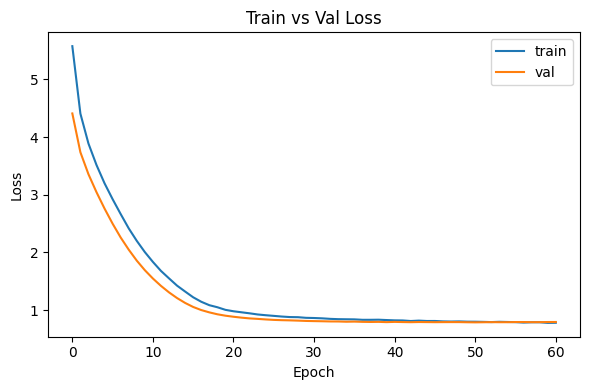

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(history["train"], label="train")
plt.plot(history["val"],   label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Val Loss")
plt.legend()
plt.tight_layout()
plt.show()


## 8. Test 세트 최종 평가

In [13]:
model.eval()
test_loss, n = 0.0, 0

with torch.no_grad():
    for xb, yR, yI, yS, yT, yP, yB in test_loader:
        xb, yR, yI, yS, yT, yP, yB = xb.to(device), yR.to(device), yI.to(device), yS.to(device), yT.to(device), yP.to(device), yB.to(device)
        tl = loss_fn(model(xb), yR, yI, yS, yT, yP, yB)
        if not torch.isnan(tl) and not torch.isinf(tl):
            test_loss += tl.item() * len(xb)
            n += len(xb)

test_avg = test_loss / n if n > 0 else float('inf')
print(f"Test loss: {test_avg:.4f}")


Test loss: 0.7808


# =========================================
# 🔍 9. Dummy 입력 → 모델 예측 & 읽기-쉬운 출력
# =========================================

In [17]:
import pandas as pd
import numpy as np

dummy_input = {
    "LanguageHaveWorkedWith":  ["Python", "C"],
    "DatabaseHaveWorkedWith":  ["SQLite"],
    "PlatformHaveWorkedWith":  ["Amazon Web Services (AWS)"],
    "WebframeHaveWorkedWith":  ["FastAPI", "React", "Flask"],
    "EmbeddedHaveWorkedWith":  ["GNU GCC"],
    "MiscTechHaveWorkedWith":  ["Docker", "NumPy", "Torch/PyTorch"],
    "ToolsTechHaveWorkedWith": ["Docker"],
    "ProfessionalTech":        ["AI-assisted technology tool(s)"],
}

# ─── 안전하게 transform (학습 시 클래스 기준)
x_dummy = np.hstack([
    mlb[c].transform([[v for v in dummy_input.get(c, []) if v in mlb[c].classes_]])
    for c in multi_cols
]).astype("float32")

# ─── 모델 예측
model.eval()
with torch.no_grad():
    r_prob, i_prob, s_hat, t_hat, p_prob, b_hat = model(torch.tensor(x_dummy).to(device))

r_prob, i_prob = r_prob.cpu().numpy()[0], i_prob.cpu().numpy()[0]
s_hat, t_hat   = s_hat.cpu().numpy()[0], t_hat.cpu().numpy()[0]
p_prob         = p_prob.cpu().numpy()[0]
b_hat_scalar   = b_hat.cpu().item()
b_hat_rescaled = scaler_boost.inverse_transform(np.array([[b_hat_scalar]]))[0, 0]

# ─── 라벨명
role_cols = raw["DevType"].str.get_dummies(";").columns
top_role_idx = np.argsort(-r_prob)[:3]
top_roles = role_cols[top_role_idx]

sal_preds = scaler.inverse_transform(s_hat[top_role_idx].reshape(-1,1)).flatten()
sat_preds = t_hat[top_role_idx]

# ─── 보완 스택: 모델 확률 기반
top_stacks = [skill_space[i] for i in np.argsort(-p_prob)[:3]]

# ─── 결과 표 생성
role_stats = []
for i, role in enumerate(top_roles):
    role_stats.append({
        "직무(모델)": role,
        "예상 연봉(모델)": f"{sal_preds[i]:,.0f}원",
        "예상 만족도(모델)": f"{sat_preds[i]:.2f}/10",
        "추천 보완 스택(모델)": ", ".join(top_stacks),
        "보완 시 연봉 향상(모델)": f"{b_hat_rescaled:,.0f}원",
    })

# ─── 출력
print("모델 예측 산업군:", ", ".join(raw["Industry"].str.get_dummies(";").columns[np.argsort(-i_prob)[:3]]))
pd.DataFrame(role_stats)


모델 예측 산업군: Software Development, Internet, Telecomm or Information Services, Healthcare


,직무(모델),예상 연봉(모델),예상 만족도(모델),추천 보완 스택(모델),보완 시 연봉 향상(모델)
0,"Developer, full-stack","125,752,656원",7.97/10,"Docker, SQL, Bash/Shell (all shells)","11,551원"
1,"Developer, back-end","132,137,504원",6.41/10,"Docker, SQL, Bash/Shell (all shells)","11,551원"
2,"Developer, embedded applications or devices","125,929,992원",6.81/10,"Docker, SQL, Bash/Shell (all shells)","11,551원"


# 10. Baseline과 비교

10-1. Top-K 최근접 (KNN baseline)

In [18]:
# ─────────────────── Top-K 최근접 baseline ───────────────────
from sklearn.neighbors import NearestNeighbors
import numpy as np

K_NEI = 50        # 최근접 이웃 개수
# 학습 세트 KNN 피팅 (cosine)
knn = NearestNeighbors(n_neighbors=K_NEI,
                       metric="cosine",
                       n_jobs=-1).fit(X_train)

# 훈련셋에서 "대표 연봉·만족도 스칼라" 벡터
yS_scalar_train = np.nanmax(np.where(np.isnan(yS_train), -np.inf, yS_train), axis=1)
yS_scalar_train[np.isinf(yS_scalar_train)] = 0
yT_scalar_train = np.nanmax(np.where(np.isnan(yT_train), -np.inf, yT_train), axis=1)
yT_scalar_train[np.isinf(yT_scalar_train)] = 0

def knn_predict(Xq):
    dists, idx = knn.kneighbors(Xq, return_distance=True)
    sims  = 1 - dists

    R_pred = yR_train[idx].mean(1)           # 직무 확률
    I_pred = yI_train[idx].mean(1)           # 산업 확률
    P_pred = yP_train[idx].mean(1)           # 보완 스택 확률 (multi-label)

    sims_sum = sims.sum(1)
    sims_sum[sims_sum == 0] = 1e-8           # 0-division 방지

    S_pred = (yS_scalar_train[idx] * sims).sum(1) / sims_sum   # 연봉
    T_pred = (yT_scalar_train[idx] * sims).sum(1) / sims_sum   # 만족도
    B_pred = (yB_train[idx]          * sims).sum(1) / sims_sum # 연봉 향상

    return R_pred, I_pred, S_pred, T_pred, P_pred, B_pred

R_knn, I_knn, S_knn, T_knn, P_knn, B_knn = knn_predict(X_test)


10-2. CatBoost baseline (멀티-레이블/레이블별 회귀)

In [20]:
# ─────────────────── CatBoost baseline ───────────────────
!pip install -q catboost
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.multioutput import MultiOutputClassifier, MultiOutputRegressor
import numpy as np

# NaN → 0 (회귀 타깃)
yS_train_fill = np.nan_to_num(yS_train, nan=0.0)
yT_train_fill = np.nan_to_num(yT_train, nan=0.0)

# [중요] yP_train (보완 스택) 중 전부 0인 열 제거
non_zero_cols = (yP_train.sum(axis=0) > 0)
yP_train_filtered = yP_train[:, non_zero_cols]
yP_test_filtered  = yP_test[:,  non_zero_cols]

# ─ 다중-라벨 분류기
clf_role = MultiOutputClassifier(
    CatBoostClassifier(iterations=300, depth=6, learning_rate=0.1,
                       verbose=False, loss_function='Logloss'))

clf_ind = MultiOutputClassifier(
    CatBoostClassifier(iterations=300, depth=6, learning_rate=0.1,
                       verbose=False, loss_function='Logloss'))

clf_stack = MultiOutputClassifier(
    CatBoostClassifier(iterations=300, depth=6, learning_rate=0.1,
                       verbose=False, loss_function='Logloss'))

# ─ 다중 회귀기
reg_sal = MultiOutputRegressor(
    CatBoostRegressor(iterations=300, depth=6, learning_rate=0.1,
                      verbose=False, loss_function='MAE'))

reg_sat = MultiOutputRegressor(
    CatBoostRegressor(iterations=300, depth=6, learning_rate=0.1,
                      verbose=False, loss_function='RMSE'))

reg_boost = CatBoostRegressor(
    iterations=300, depth=6, learning_rate=0.1,
    verbose=False, loss_function='MAE')

# ─ 학습
clf_role.fit(X_train, yR_train)
clf_ind.fit(X_train, yI_train)
clf_stack.fit(X_train, yP_train_filtered)     # 필터링된 보완 스택만 학습
reg_sal.fit(X_train, yS_train_fill)
reg_sat.fit(X_train, yT_train_fill)
reg_boost.fit(X_train, yB_train)

# ─ 예측
R_cat = np.stack([p[:,1] for p in clf_role.predict_proba(X_test)], axis=1)
I_cat = np.stack([p[:,1] for p in clf_ind.predict_proba(X_test)], axis=1)
P_cat_filtered = np.stack([p[:,1] for p in clf_stack.predict_proba(X_test)], axis=1)

# 전체 보완 스택 차원으로 복원
P_cat = np.zeros((X_test.shape[0], yP_train.shape[1]), dtype="float32")
P_cat[:, non_zero_cols] = P_cat_filtered

S_cat_full = reg_sal.predict(X_test)   # (N, n_role)
T_cat_full = reg_sat.predict(X_test)
B_cat = reg_boost.predict(X_test)      # (N,)

# 확률이 가장 높은 직무 기준으로 연봉·만족도 스칼라화
max_role_idx = R_cat.argmax(1)
S_cat = S_cat_full[np.arange(len(X_test)), max_role_idx]
T_cat = T_cat_full[np.arange(len(X_test)), max_role_idx]


10—3. 공통 평가 함수 & 비교 표

In [21]:
# ─────────────────── 공통 메트릭 & 비교 ───────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd, numpy as np, torch

def recall_at_k(y_true, y_prob, k):
    topk = np.argsort(-y_prob, axis=1)[:, :k]
    return np.mean([y_true[i, idx].max() for i, idx in enumerate(topk)])

def evaluate(name, R, I, S, T, P, B):
    r1 = recall_at_k(yR_test, R, 1); r3 = recall_at_k(yR_test, R, 3)
    i1 = recall_at_k(yI_test, I, 1); i3 = recall_at_k(yI_test, I, 3)
    p3 = recall_at_k(yP_test, P, 3)

    # 연봉
    true_sal_raw = np.nanmax(yS_test, axis=1)
    idx_sal = ~np.isnan(true_sal_raw)
    sal_mae = mean_absolute_error(
        scaler.inverse_transform(true_sal_raw[idx_sal,None]).flatten(),
        scaler.inverse_transform(S[idx_sal,None]).flatten())

    # 만족도
    true_sat_raw = np.nanmax(yT_test, axis=1)
    idx_sat = ~np.isnan(true_sat_raw)
    sat_rmse = np.sqrt(mean_squared_error(true_sat_raw[idx_sat], T[idx_sat]))

    # 연봉 향상
    boost_mae = mean_absolute_error(
        scaler_boost.inverse_transform(yB_test.reshape(-1,1)).flatten(),
        scaler_boost.inverse_transform(B.reshape(-1,1)).flatten())

    return pd.Series({
        "R@1_role":r1, "R@3_role":r3,
        "R@1_ind":i1,  "R@3_ind":i3,
        "Stack_R@3":p3,
        "Salary_MAE":sal_mae,
        "Sat_RMSE":sat_rmse,
        "Boost_MAE":boost_mae
    }, name=name)

# ─ TabTransformer+ 예측
model.eval()
with torch.no_grad():
    R_dl, I_dl, S_dl_full, T_dl_full, P_dl, B_dl = model(torch.tensor(X_test).to(device))
R_dl, I_dl, P_dl = R_dl.cpu().numpy(), I_dl.cpu().numpy(), P_dl.cpu().numpy()
B_dl = B_dl.cpu().numpy()
idx_max = R_dl.argmax(1)
S_dl = S_dl_full.cpu().numpy()[np.arange(len(X_test)), idx_max]
T_dl = T_dl_full.cpu().numpy()[np.arange(len(X_test)), idx_max]

# ─ 결과 비교
results = pd.concat([
    evaluate("TabTransformer+", R_dl, I_dl, S_dl, T_dl, P_dl, B_dl),
    evaluate("TopK",            R_knn, I_knn, S_knn, T_knn, P_knn, B_knn),
    evaluate("CatBoost",        R_cat, I_cat, S_cat, T_cat, P_cat, B_cat)
], axis=1).T

results.round(4)


<ipython-input-21-008d78ddb409>:15: RuntimeWarning: All-NaN slice encountered
  true_sal_raw = np.nanmax(yS_test, axis=1)
<ipython-input-21-008d78ddb409>:15: RuntimeWarning: All-NaN slice encountered
  true_sal_raw = np.nanmax(yS_test, axis=1)
<ipython-input-21-008d78ddb409>:15: RuntimeWarning: All-NaN slice encountered
  true_sal_raw = np.nanmax(yS_test, axis=1)


,R@1_role,R@3_role,R@1_ind,R@3_ind,Stack_R@3,Salary_MAE,Sat_RMSE,Boost_MAE
TabTransformer+,0.5360,0.8281,0.3927,0.5116,0.5022,6.687133e+07,2.1306,9505.5176
TopK,0.5959,0.8672,0.3927,0.5271,0.8888,6.459563e+07,2.1140,9235.0664
CatBoost,0.6155,0.8745,0.3878,0.5385,0.9939,6.695943e+07,3.7683,8986.6384
